In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
import scipy.stats as stats

# Part A

1. Load csv file

In [ ]:
df = pd.read_csv('hiring-1.csv')

2. Show shape, dtypes and basic summary stats

In [ ]:
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,NaN,7,72000
7,eleven,7.0,8,80000


In [ ]:
df.shape

(8, 4)

In [ ]:
df.dtypes

,0
experience,object
test_score(out of 10),float64
interview_score(out of 10),int64
salary($),int64


In [ ]:
df.isna().sum()

,0
experience,2
test_score(out of 10),1
interview_score(out of 10),0
salary($),0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   experience                  6 non-null      object 
 1   test_score(out of 10)       7 non-null      float64
 2   interview_score(out of 10)  8 non-null      int64  
 3   salary($)                   8 non-null      int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 388.0+ bytes


In [ ]:
df.describe()

,test_score(out of 10),interview_score(out of 10),salary($)
count,7.000000,8.000000,8.00000
mean,7.857143,7.875000,63000.00000
std,1.345185,1.642081,11501.55269
min,6.000000,6.000000,45000.00000
25%,7.000000,6.750000,57500.00000
50%,8.000000,7.500000,63500.00000
75%,8.500000,9.250000,70500.00000
max,10.000000,10.000000,80000.00000


In [ ]:
#Renaming columns
df.rename(columns={"test_score(out of 10)":"test_score","interview_score(out of 10)":"interview_score","salary($)":"salary"},inplace=True)

In [ ]:
df.columns

Index(['experience', 'test_score', 'interview_score', 'salary'], dtype='object')

3. Visualize : Histogram, Scatterplots and Correlation matrix

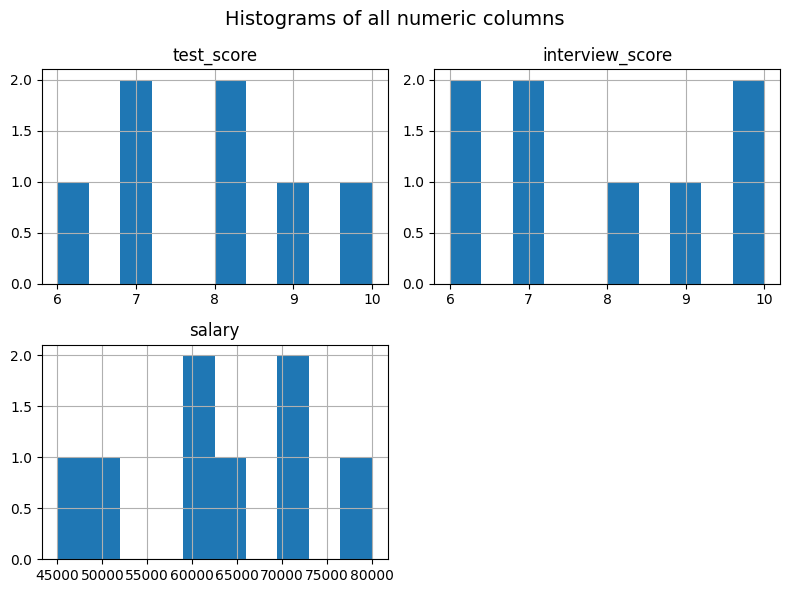

In [ ]:
df.hist(figsize=(8,6))
plt.suptitle("Histograms of all numeric columns", fontsize=14)
plt.tight_layout()
plt.show()


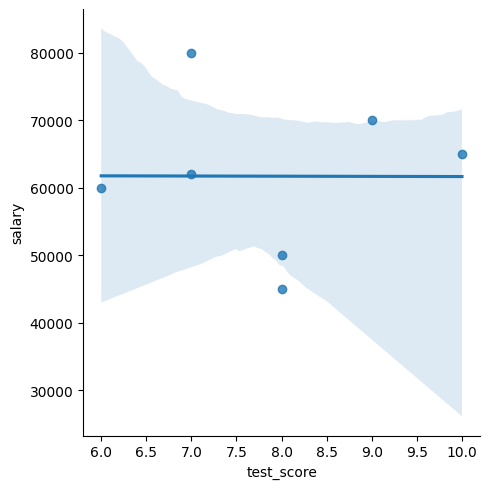

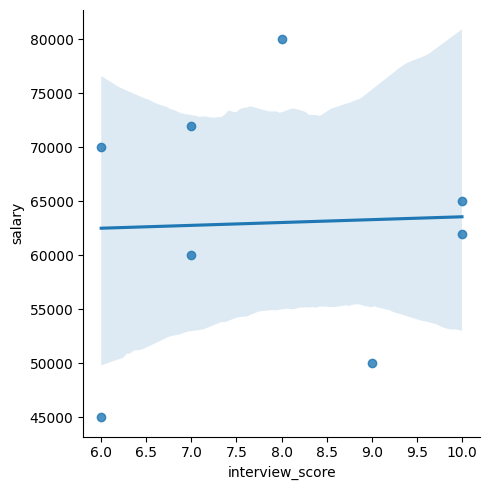

In [ ]:

sns.lmplot(x='test_score', y='salary', data=df)
sns.lmplot(x='interview_score', y='salary', data=df)
plt.show()

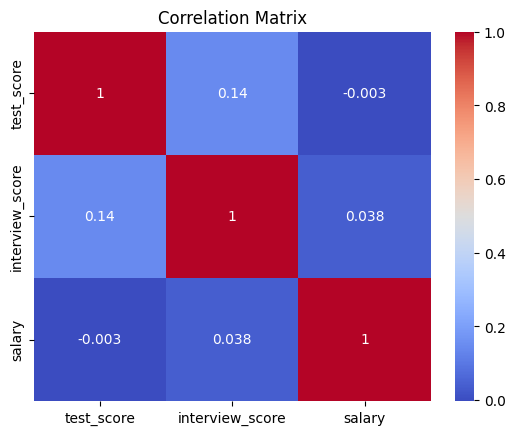

In [ ]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Summary Insights:

Linearity:
Scatterplots between both test_score/interview_score and salary show weak positive or almost flat trends, suggesting limited linear relationships in this small sample.
The correlation matrix also confirms low correlations (|r| < 0.15).

Outliers:
A few salary points (around 80,000  and  45,000) appear distant from the main cluster, potentially influencing the regression line.
However, the small dataset size makes it difficult to conclude strong outlier impact.

Skewness:
Histograms indicate fairly symmetric distributions for test_score and interview_score.
The salary distribution shows slight right skew due to one higher-salary observation.

Feature Strength:
Since correlations are very low, salary may depend on other unobserved variables (e.g., experience, education), not just test or interview scores.

Data Readiness:
Numeric features are well-bounded (scores 6–10), making them suitable for scaling and feature interactions later in the pipeline.

# Part B - Data Cleaning and Feature Engineering

1. Normalize experience column

In [ ]:
exp_map = {
    'two': 2,
    'three': 3,
    'four': 4,
    'five': 5,
    'six': 6,
    'seven': 7,
    'eight': 8,
    'nine': 9,
    'ten': 10,
    'eleven': 11
}

In [ ]:
df['experience'] = df['experience'].replace(exp_map)

/tmp/ipython-input-4202733734.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['experience'] = df['experience'].replace(exp_map)


In [ ]:
df

,experience,test_score,interview_score,salary
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,5.0,6.0,7,60000
3,2.0,10.0,10,65000
4,7.0,9.0,6,70000
5,3.0,7.0,10,62000
6,10.0,NaN,7,72000
7,11.0,7.0,8,80000


2. Imputing experience and test_score column

In [ ]:
df['experience'].fillna(df['experience'].median(), inplace=True)
df['test_score'].fillna(df['test_score'].median(), inplace=True)
## Both columns ar eimputed with median of the respective columns as it is the exact middle value of all entries in that column


/tmp/ipython-input-1390917833.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['experience'].fillna(df['experience'].median(), inplace=True)
/tmp/ipython-input-1390917833.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [ ]:
df['experience'] = df['experience'].astype(int)
df['test_score'] = df['test_score'].astype(int)

3. Scale features (keep both with and without scaling)

In [ ]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [ ]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['experience', 'test_score', 'interview_score']])
X_scaled = pd.DataFrame(X_scaled, columns=['experience', 'test_score', 'interview_score'])

print("\nScaled Feature Preview:\n", X_scaled.head())


Scaled Feature Preview:
    experience  test_score  interview_score
0   -0.086066    0.107211         0.732410
1   -0.086066    0.107211        -1.220683
2   -0.430331   -1.608169        -0.569652
3   -1.463127    1.822591         1.383440
4    0.258199    0.964901        -1.220683


 4. Optional engineered features

In [ ]:
# Interaction term: experience × interview_score
df['exp_int'] = df['experience'] * df['interview_score']

# Nonlinear term: experience^2
df['exp_sq'] = df['experience'] ** 2

# Overall Score out of 100
df['overall_score'] = df['interview_score'] * df['test_score']

In [ ]:
from sklearn.impute import SimpleImputer
import joblib

In [ ]:
# Define numeric columns
num_features = ['experience', 'test_score', 'interview_score']

# Define preprocessing
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])

# Combine transformations
preprocessor = ColumnTransformer(
    transformers=[('num', num_transformer, num_features)]
)

# Full pipeline (with model placeholder)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Save deliverable
joblib.dump(pipeline, 'data_cleaning_pipeline.pkl')
print("✅ Pipeline saved as data_cleaning_pipeline.pkl")

✅ Pipeline saved as data_cleaning_pipeline.pkl


# Part C : Baselines and Models

Training Models

In [ ]:
X = df[['experience', 'test_score', 'interview_score','overall_score','exp_sq','exp_int']]
y = df['salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
X_train

,experience,test_score,interview_score,overall_score,exp_sq,exp_int
0,6,8,9,72,36,54
7,11,7,8,56,121,88
2,5,6,7,42,25,35
4,7,9,6,54,49,42
3,2,10,10,100,4,20
6,10,8,7,56,100,70


1. Baseline Mean Regressor

In [ ]:
baseline_pred = [y_train.mean()] * len(y_test)
print("\nBaseline MAE:", mean_absolute_error(y_test, baseline_pred))


Baseline MAE: 12666.666666666672


2. Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

3. Ridge

In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

4. Random Forest

In [ ]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

Evaluation using K-fold, MAE, R2, RMSE and a Custom Accuracy (calculated as 1 - (|actuals-predicted\/actuals))

In [ ]:
y_pred_lr,y_pred_ridge,y_pred_rf

(array([68243.73404498, 57214.50641468]),
 array([64988.44542279, 57706.83892483]),
 array([58760., 60960.]))

In [ ]:
y_test

,salary
1,45000
5,62000


In [ ]:

# Evaluation
def evaluate(y_true, y_pred, name):
    abs_err = np.abs(y_true - y_pred)
    acc = 1 - (abs_err / y_true)
    acc = np.clip(acc, 0, 1)  # avoid negatives
    mean_acc = np.mean(acc)

    print(f"\n{name} Results:")
    print("MAE :", round(mean_absolute_error(y_true, y_pred), 2))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_true, y_pred)), 2))
    print("R²   :", round(r2_score(y_true, y_pred), 3))
    print("Custom Accuracy (1 - |err/actual|):", round(mean_acc * 100, 2), "%")
    return mean_acc

acc_lr = evaluate(y_test, y_pred_lr, "Linear Regression")
acc_ridge = evaluate(y_test, y_pred_ridge, "Ridge Regression")
acc_rf = evaluate(y_test, y_pred_rf, "Random Forest")


Linear Regression Results:
MAE : 14014.61
RMSE: 16780.53
R²   : -2.897
Custom Accuracy (1 - |err/actual|): 70.31 %

Ridge Regression Results:
MAE : 12140.8
RMSE: 14456.3
R²   : -1.893
Custom Accuracy (1 - |err/actual|): 74.33 %

Random Forest Results:
MAE : 7400.0
RMSE: 9757.54
R²   : -0.318
Custom Accuracy (1 - |err/actual|): 83.87 %


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr, X, y, cv=kf, scoring='r2')
print("\nCross-validation R2 scores:", cv_scores)
print("Average R2:", cv_scores.mean())



Cross-validation R2 scores: [  -2.89738492 -669.56926323  -11.55871301           nan           nan]
Average R2: nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


# Part D : Diagnostics and Validity


1(a). Residual Analysis - For LR Model

In [ ]:
residuals = y_test - y_pred_lr

In [ ]:
residuals

,salary
1,-23243.734045
5,4785.493585


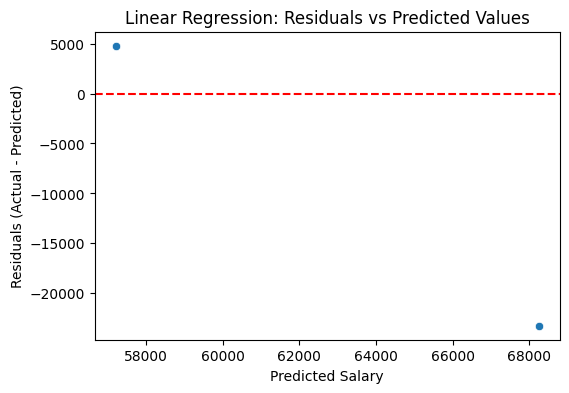

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred_lr, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Linear Regression: Residuals vs Predicted Values")
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals (Actual - Predicted)")
plt.show()

1(b). Q–Q plot (to check if residuals are roughly normal)

In [ ]:
import statsmodels.api as sm

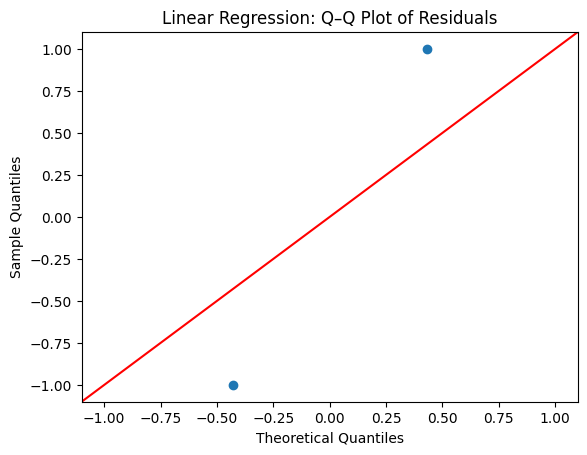

In [ ]:

sm.qqplot(residuals, line='45', fit=True)
plt.title("Linear Regression: Q–Q Plot of Residuals")
plt.show()

2. Influence/Outlier Check

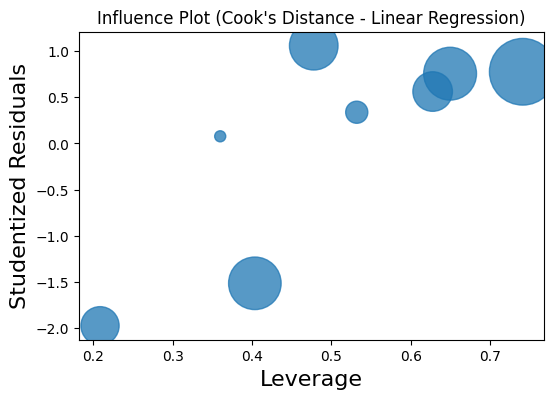

In [ ]:
# Refit model in statsmodels for diagnostic plots
import statsmodels.api as sm
# Remove multicollinear columns for diagnostics
X_diag = X[['experience', 'test_score', 'interview_score']]
X_const = sm.add_constant(X_diag)

model_lr = sm.OLS(y, X_const).fit()

fig, ax = plt.subplots(figsize=(6,4))
sm.graphics.influence_plot(model_lr, ax=ax, criterion="cooks")
plt.title("Influence Plot (Cook's Distance - Linear Regression)")
plt.show()


3. Uncertainity - 95% Interval

In [ ]:

# Get predictions and standard error
predictions = model_lr.get_prediction(X_const)
summary_frame = predictions.summary_frame(alpha=0.05)  # 95% CI

# Combine key results
intervals_lr = pd.DataFrame({
    "Predicted": summary_frame["mean"],
    "Lower_95%": summary_frame["obs_ci_lower"],
    "Upper_95%": summary_frame["obs_ci_upper"]
})
print(intervals_lr)


      Predicted     Lower_95%      Upper_95%
0  65756.097561  29785.392184  101726.802937
1  56975.609756  18209.486062   95741.733450
2  54422.764228  12395.778909   96449.749546
3  60097.560976  16919.706830  103275.415122
4  61121.951220  21344.230399  100899.672040
5  58910.569106  18409.944398   99411.193813
6  71154.471545  32996.324968  109312.618121
7  75560.975610  33815.164921  117306.786298


# Part E : Required Predictions

In [ ]:

# Creating the two new cases ----
# (a) 2 yrs experience, test=9, interview=6
# (b) 12 yrs experience, test=10, interview=10
new_data = pd.DataFrame({
    "experience": [2, 12],
    "test_score": [9, 10],
    "interview_score": [6, 10]
})


In [ ]:

X_new = sm.add_constant(new_data)

predictions = model_lr.get_prediction(X_new)
summary_frame = predictions.summary_frame(alpha=0.05)  # 95% CI


In [ ]:

results = pd.DataFrame({
    "Case": ["(2 yrs, 9, 6)", "(12 yrs, 10, 10)"],
    "Predicted_Salary": summary_frame["mean"],
    "Lower_95%": summary_frame["obs_ci_lower"].clip(lower=0),
    "Upper_95%": summary_frame["obs_ci_upper"]
})

print("\n95% Prediction Intervals for New Cases:")
print(results.round(2))



95% Prediction Intervals for New Cases:
               Case  Predicted_Salary  Lower_95%  Upper_95%
0     (2 yrs, 9, 6)          47056.91        0.0   94743.13
1  (12 yrs, 10, 10)          88227.64    28396.8  148058.49


The Linear Regression model predicts salaries reasonably but with high uncertainty, especially for candidates with fewer years of experience.
The wide prediction intervals (e.g., $0–$94K) indicate that the model struggles with small data and linear assumptions.
This suggests the model is not very reliable for precise salary estimation and would benefit from more data or a non-linear model like Random Forest.